# Optogenetic simulation: thresholding + trackpy + top-edge stimulation

Demonstrates the full rtm-pymmcore pipeline using the virtual-microscope optogenetic backend.
- **Segmentation:** Simple thresholding (Gaussian blur → Otsu → distance transform → watershed)
- **Tracking:** Trackpy
- **Stimulation:** Illuminate the top 10 % (y-direction) of each cell with mask dilation

In [9]:
import sys, os
from virtual_microscope.backends.optogenetic import setup_optogenetic
from rtm_pymmcore.microscope.simulation import UniMMCoreSimulation
import rtm_pymmcore.core.utils as utils

# Load an simulated microscope
# core is the main interface to the microscope, exactly the same 
# interface as you would have with a microscope running with pymmcore-plus
core, sim = setup_optogenetic()
utils.print_configs(core)

# mic is the object that represents the microscope
# anything specific to your microscope, you would implement in that class
mic = UniMMCoreSimulation(mmc=core)
mic.init_scope()  # detect SLM device for optogenetic stimulation

Config Groups
└── Channel
    ├── DAPI
    ├── membrane
    └── phase-contrast

## Segmentation: Watershed
Real experiments would use `cellpose` / `stardist` / `convpaint` for segmentation, here we use simple thresholding approach to remove dependencies and speed up processing for testing.

In [10]:
import numpy as np
from skimage.filters import gaussian, threshold_otsu
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label
from scipy import ndimage
from rtm_pymmcore.segmentation.base import Segmentator


class WatershedSegmentator(Segmentator):
    """Gaussian blur -> Otsu threshold -> distance transform -> watershed."""

    def segment(self, image: np.ndarray) -> np.ndarray:
        blurred = gaussian(image, sigma=3)
        thresh = threshold_otsu(blurred)
        binary = blurred > thresh
        distance = ndimage.distance_transform_edt(binary)
        coords = peak_local_max(distance, min_distance=20, labels=binary)
        markers = np.zeros(distance.shape, dtype=bool)
        markers[tuple(coords.T)] = True
        markers = label(markers)
        return watershed(-distance, markers, mask=binary)
    
segmentator = WatershedSegmentator()

You can also use multiple segmentation tools, if you want to segment e.g. a colony of cells as whole but also an individual cells.
In this example we just use one. Each segmentation gets a name, here `labels`.

In [11]:
from rtm_pymmcore.core.data_structures import SegmentationMethod

segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=segmentator,
        use_channel=0,
        save_tracked=True,
    )
]

# Tracking: trackpy
For tracking, here we use `trackpy`. The most important parameter to tune is the search range. What is the maximum distance the centroid of your cells move from frame to frame?

In [12]:
from rtm_pymmcore.tracking.trackpy import TrackerTrackpy

tracker = TrackerTrackpy(search_range=15)

# Feature extraction
In the feature extraction function, you define all the image processing and analysis that you want to calculate during the experiment. A good starting point is to use the skimage `regionprops` functions, but this can be expanded a lot. For example to quantify biosensor activity with FRET probes that require processing, or translocation based sensors like ERK-KTR, that indicate ERK activity based on the ratio of biosensor in the nucleus vs. cytosol.

In [13]:
import skimage.measure
import pandas as pd
from rtm_pymmcore.feature_extraction.base import FeatureExtractor

class SimpleFE(FeatureExtractor):
    def __init__(self, used_mask):
        self.used_mask = used_mask
        super().__init__()

    def extract_features(self, labels, image, df_tracked=None, metadata=None):
        table = skimage.measure.regionprops_table(
            labels[self.used_mask], properties=["label", "area"]
        )
        table = pd.DataFrame.from_dict(table)
        return table, None

# "labels" is the name of the segmentation method we defined above
feature_extractor = SimpleFE("labels")

## Stimulation A: top-edge illumination
The `Stim` class is where you define the stimulation logic. Based on the microscope image / segmentation / tracking data, where do you want to photoactivate?

In this example, we only use the mask image to find the top-region of each cell. This should induce directed migration in the cells in the simulation, mimicking experiments with optogenetic actuators like optoTIAM (activates Rac) or optoFGFR (activates donwstream FGF signalling).

In [14]:
from rtm_pymmcore.stimulation.base import Stim
from skimage.morphology import disk, dilation
from skimage.measure import regionprops


class StimUp(Stim):
    """Illuminate the top *fraction* of each cell's y-extent, dilated by disk(3)."""

    def __init__(self, fraction):
        super().__init__()
        self.use_labels = True
        self.use_imgs = False
        self.fraction = fraction

    def get_stim_mask(self, label_images, metadata=None, img=None, tracks=None):
        labels = label_images["labels"]
        stim_mask = np.zeros(labels.shape, dtype=np.uint8)
        selem = disk(3)

        for prop in regionprops(labels):
            minr, minc, maxr, maxc = prop.bbox
            y_cutoff = minr + self.fraction * (maxr - minr)

            cell_mask = labels == prop.label
            rows, cols = np.where(cell_mask)
            top_pixels = rows < y_cutoff
            if not top_pixels.any():
                continue

            local = np.zeros_like(labels, dtype=np.uint8)
            local[rows[top_pixels], cols[top_pixels]] = 1
            local = dilation(local, footprint=selem)
            stim_mask = np.maximum(stim_mask, local)

        return stim_mask, None
    
stimulator_up = StimUp(fraction=0.2)

## Stimulation B: track-aware stimulator

The previous example only used the labels image, now we additionally use the `tracks` DataFrame (passed automatically by the pipeline) to steer
even-numbered particles upward and odd-numbered particles downward. This should make half our cells move up, and the other half down.

We're using the `trackpy` syntax of `label` and `particle`:
- `label` is the integer assigned to each cell mask in the segmentation output
- `particle` is the track ID of each cell that stays consistent across timepoints.

In [15]:
class StimUpDown(Stim):
    """Steer cells based on particle ID: even → up, odd → down.

    Illuminates the top or bottom *fraction* of each cell's y-extent,
    using the tracks DataFrame to look up the particle ID for each label.
    On the first frame (no tracks yet), return an empty mask.
    """

    def __init__(self, fraction=0.15):
        super().__init__()
        self.use_labels = True
        self.use_imgs = False
        self.fraction = fraction

    def get_stim_mask(self, label_images, metadata=None, img=None, tracks=None):
        labels = label_images["labels"]
        stim_mask = np.zeros(labels.shape, dtype=np.uint8)
        selem = disk(3)

        if tracks is None or tracks.empty:
            return stim_mask, None

        # Build label → particle mapping from the current frame's tracks
        current = tracks[tracks["timestep"] == tracks["timestep"].max()]
        label_to_particle = dict(zip(current["label"], current["particle"]))

        for prop in regionprops(labels):
            minr, minc, maxr, maxc = prop.bbox
            pid = label_to_particle.get(prop.label, 0)

            if pid % 2 == 0:
                # Even particle → illuminate top edge (push up)
                y_cutoff = minr + self.fraction * (maxr - minr)
                select = lambda rows: rows < y_cutoff
            else:
                # Odd particle → illuminate bottom edge (push down)
                y_cutoff = maxr - self.fraction * (maxr - minr)
                select = lambda rows: rows > y_cutoff

            cell_mask = labels == prop.label
            rows, cols = np.where(cell_mask)
            edge_pixels = select(rows)
            if not edge_pixels.any():
                continue

            local = np.zeros_like(labels, dtype=np.uint8)
            local[rows[edge_pixels], cols[edge_pixels]] = 1
            local = dilation(local, footprint=selem)
            stim_mask = np.maximum(stim_mask, local)

        return stim_mask, None
    
stimulator_up_down = StimUpDown(fraction=0.2)

## Build the pipeline

Once we have a segmentator, tracker, feature extractor and stimulator, we can assemble the whole pipeline.

In [16]:
from rtm_pymmcore.core.pipeline import ImageProcessingPipeline
import shutil

path = "/tmp/test_optogenetic_sim"

# Clean data from any previous run
if os.path.exists(path):
    shutil.rmtree(path)
    print(f"Cleaned previous data at {path}")

# Set up the pipeline with the tools we've set up above
pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=stimulator_up,
)


Cleaned previous data at /tmp/test_optogenetic_sim
Directory /tmp/test_optogenetic_sim/raw created 
Directory /tmp/test_optogenetic_sim/tracks created 
Directory /tmp/test_optogenetic_sim/stim_mask created 
Directory /tmp/test_optogenetic_sim/stim created 
Directory /tmp/test_optogenetic_sim/particles created 
Directory /tmp/test_optogenetic_sim/labels created 


## Preview segmentation + stimulation

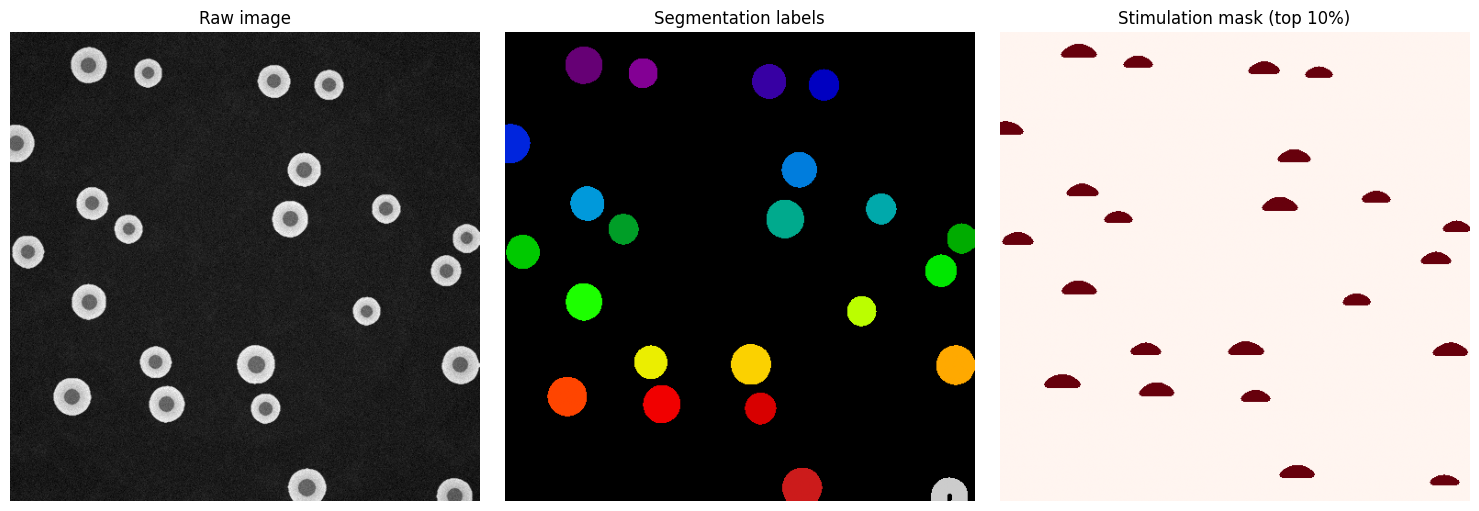

In [17]:
import matplotlib.pyplot as plt

core.setConfig("Channel", "phase-contrast")
core.setXYPosition(0, 0)
core.snapImage()
test_img = core.getImage()

labels_preview = segmentator.segment(test_img)
mask_preview, _ = stimulator_up.get_stim_mask(
    label_images={"labels": labels_preview}, metadata={}
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Raw image")
axes[1].imshow(labels_preview, cmap="nipy_spectral")
axes[1].set_title("Segmentation labels")
axes[2].imshow(mask_preview, cmap="Reds")   
axes[2].set_title("Stimulation mask (top 10%)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Set up the experiment
How many frames and fovs, what interval, when to stimulate?

Use `RTMSequence` to set up the experiment. It's a subclass of [`MDASequence`](https://pymmcore-plus.github.io/pymmcore-plus/examples/mda/) subclass that yields `RTMEvent` objects when iterated (instead of `MDAEvents`). 

This adds support for:
- Stimulation frames & channels (special channel used for photoactivation, SLM mask only applies to this channel)
- Extra metadata, e.g. as arguments for the processing pipeline

Concatenate multiple sequences with `+` for multi-phase experiments.

First, a simple experiment without photostimulation:

In [18]:
from rtm_pymmcore.core.data_structures import RTMSequence
from useq import MDASequence
from rtm_pymmcore.core.utils import events_to_dataframe

# Simple experiment with no stimulation...
timelapse_mda = MDASequence(
    time_plan={"interval": 1.0, "loops": 50},
    stage_positions=[(256.0, 256.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
)

# ... is equivalent to the RTMSequence version:
timelapse_rtm = RTMSequence(
    time_plan={"interval": 1.0, "loops": 50},
    stage_positions=[(256.0, 256.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
)

events_mda = list(timelapse_mda)

# print a dataframe to get an overview of the experiment plan:
events_to_dataframe(events_mda).head()

,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,stim,optocheck_channels,optocheck
0,0,0,0.0,256.0,256.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False
1,0,1,1.0,256.0,256.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False
2,0,2,2.0,256.0,256.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False
3,0,3,3.0,256.0,256.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False
4,0,4,4.0,256.0,256.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False


For a stimulation experiment, you can use the following syntax. Note the extra `stim_channels`, `stim_frames` and `rtm_metadata` fields. The metadata can contain any information that you want to save with your experiment, or data that is required by your pipeline tools. E.g. if you want one FOV to use `stim-up` and another FOV to use `stim-down`, you could add this info here and read it out in the respective functions.

In [19]:
from rtm_pymmcore.core.data_structures import RTMSequence
from rtm_pymmcore.core.utils import events_to_dataframe

n_frames = 40
stim_start = 0
stim_end = 40

acq = RTMSequence(
    time_plan={"interval": 1.0, "loops": n_frames},
    stage_positions=[(0.0, 0.0, 0.0)], #xyz
    channels=[{"config": "phase-contrast", "exposure": 50}], #channels to acquire
    stim_channels=[{"config": "phase-contrast", "exposure": 100}], #channels for photoactivation
    stim_frames=range(stim_start, stim_end), #frames where photoactivation is ON 
    rtm_metadata={"treatment_name": "top-edge-stim"},
    )

events = list(acq)
df_summary = events_to_dataframe(events)
print(f"{len(events)} RTMEvents created")
df_summary.head()

40 RTMEvents created


,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,stim,optocheck_channels,optocheck,treatment_name,stim_power,stim_exposure
0,0,0,0.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 100....",True,(),False,top-edge-stim,None,100.0
1,0,1,1.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 100....",True,(),False,top-edge-stim,None,100.0
2,0,2,2.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 100....",True,(),False,top-edge-stim,None,100.0
3,0,3,3.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 100....",True,(),False,top-edge-stim,None,100.0
4,0,4,4.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 100....",True,(),False,top-edge-stim,None,100.0


In [20]:
# Note that you can also concat sequences:

# Simple baseline timelapse
baseline = RTMSequence(
    time_plan={"interval": 1.0, "loops": 2},
    stage_positions=[(0.0, 0.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
)

# Photoactivation experiment
stimulus = RTMSequence(
    time_plan={"interval": 1.0, "loops": 30},
    stage_positions=[(0.0, 0.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    stim_frames=range(30),  # Stimulate all 2 frames in this sequence
    stim_channels=[{"config": "phase-contrast", "exposure": 50}],
)

# Stimple timelapse with acquisition of the channel marking the optogenetic actuator (optocheck)
recovery = RTMSequence(
    time_plan={"interval": 1.0, "loops": 2},
    stage_positions=[(0.0, 0.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    optocheck_channels=[{"config": "phase-contrast", "exposure": 50}],
    optocheck_frames=[1]
)
full_experiment = baseline + stimulus + recovery
events_full = list(full_experiment)
events_to_dataframe(events_full)

,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,stim,optocheck_channels,optocheck,stim_power,stim_exposure
0,0,0,0.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,NaN,NaN
1,0,1,1.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,NaN,NaN
2,0,2,2.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
3,0,3,3.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
4,0,4,4.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
5,0,5,5.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
6,0,6,6.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
7,0,7,7.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
8,0,8,8.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0
9,0,9,9.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...","({'config': 'phase-contrast', 'exposure': 50.0...",True,(),False,NaN,50.0


And a experiment with stimulation, using the same acquisition sequence but with the `StimUpDown` stimulator active in the pipeline:

## Validate events before running

`ctrl.validate_events(events)` runs all pre-flight checks in one call:

1. **Pipeline validation** (`pipeline.validate_pipeline`) — method signatures match
   their base class, and events carry the `required_metadata` keys declared
   by each component (segmentator, tracker, feature extractor, stimulator).
2. **Hardware validation** (`mic.validate_hardware`) — channel configs exist on
   the microscope, exposure values are within the camera's limits, and device
   property values (e.g. laser power) are within their allowed range.

Validation also runs automatically at the start of `ctrl.run_experiment()`
(pass `validate=False` to skip).

To declare required metadata, add a class attribute to your component:

```python
class MyStimulator(Stim):
    required_metadata: set[str] = {"stim_fraction", "stim_target"}
    ...
```

The example below uses `StimTopEdgeMeta` (from `stimulation.base`), which reads
`stim_fraction` from event metadata instead of from the constructor. It declares
`required_metadata = {"stim_fraction"}` — forgetting to set it triggers a warning.

In [21]:
import warnings, tempfile, shutil
from rtm_pymmcore.stimulation.base import StimTopEdgeMeta
from rtm_pymmcore.core.pipeline import ImageProcessingPipeline
from rtm_pymmcore.core.controller import Controller

# Build a temporary pipeline with StimTopEdgeMeta to demo validation
_tmp = tempfile.mkdtemp()
_demo_pipeline = ImageProcessingPipeline(
    storage_path=_tmp,
    segmentators=segmentators,
    stimulator=StimTopEdgeMeta(),  # requires "stim_fraction" in metadata
)
_demo_ctrl = Controller(mic, _demo_pipeline)

# --- BAD: forgot to include stim_fraction in rtm_metadata ---
bad_acq = RTMSequence(
    time_plan={"interval": 1.0, "loops": 5},
    stage_positions=[(0, 0, 0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    stim_channels=[{"config": "phase-contrast", "exposure": 100}],
    stim_frames=range(2, 5),
    rtm_metadata={"treatment_name": "oops"},  # missing stim_fraction!
)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    ok = _demo_ctrl.validate_events(list(bad_acq))
    print(f"validate_events returned {ok}")
    for warning in w:
        print(f"  WARNING: {warning.message}")

# --- GOOD: stim_fraction provided ---
good_acq = RTMSequence(
    time_plan={"interval": 1.0, "loops": 5},
    stage_positions=[(0, 0, 0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    stim_channels=[{"config": "phase-contrast", "exposure": 100}],
    stim_frames=range(2, 5),
    rtm_metadata={"treatment_name": "fixed", "stim_fraction": 0.1},
)

print()
ok = _demo_ctrl.validate_events(list(good_acq))
print(f"validate_events returned {ok}")

shutil.rmtree(_tmp)

Directory /var/folders/zy/d2yp5vws25l6vkr2g5l4t39c0000gn/T/tmpx5sljtu4/raw created 
Directory /var/folders/zy/d2yp5vws25l6vkr2g5l4t39c0000gn/T/tmpx5sljtu4/tracks created 
Directory /var/folders/zy/d2yp5vws25l6vkr2g5l4t39c0000gn/T/tmpx5sljtu4/stim_mask created 
Directory /var/folders/zy/d2yp5vws25l6vkr2g5l4t39c0000gn/T/tmpx5sljtu4/stim created 
Directory /var/folders/zy/d2yp5vws25l6vkr2g5l4t39c0000gn/T/tmpx5sljtu4/labels created 
validate_events returned False

validate_events returned True


## Run experiment

In [22]:
import sys, io, logging, time as _time
from tqdm.auto import tqdm
from rtm_pymmcore.core.data_structures import ImgType
from rtm_pymmcore.core.controller import Controller

ctrl = Controller(mic, pipeline)

n_total = len(events)
pbar = tqdm(total=n_total, desc="Experiment", unit="frames")
_frame_count = [0]
_t0 = [None]           # wall-clock start (set on first frame)
_max_delay = [0.0]     # track worst-case delay
_late_frames = [0]     # count of frames that arrived late

# Frames arriving more than this many seconds late trigger a warning
_LATE_THRESHOLD = 0.5

def _on_frame(img, event):
    md = event.metadata or {}
    if md.get("img_type") != ImgType.IMG_RAW:
        return

    _frame_count[0] += 1
    pbar.update(1)
    
    # --- Timing check ---
    now = _time.time()
    if _t0[0] is None:
        _t0[0] = now  # first imaging frame = reference
    expected = md.get("time", 0)
    elapsed = now - _t0[0]
    delay = elapsed - expected
    _max_delay[0] = max(_max_delay[0], delay)
    late = ""
    if delay > _LATE_THRESHOLD:
        _late_frames[0] += 1
        late = f"  LATE +{delay:.1f}s"

    fov = md.get("fov", 0)
    n_cells = ctrl._analyzer.get_fov_state(fov).n_cells_latest
    ts = md.get("timestep", 0)
    pbar.set_postfix_str(
        f"frame {ts+1}/{n_total},  cells={n_cells},  delay={delay:+.2f}s{late}"
    )

core.mda.events.frameReady.connect(_on_frame)

# Suppress verbose per-frame logs from pipeline and pymmcore-plus
_stdout = sys.stdout
sys.stdout = io.StringIO()
_mda_logger = logging.getLogger("pymmcore-plus")
_prev_level = _mda_logger.level
_mda_logger.setLevel(logging.WARNING)
try:
    ctrl.run_experiment(events, stim_mode="current")
    mic.post_experiment()
    ctrl._analyzer.shutdown(wait=True)
finally:
    sys.stdout = _stdout
    _mda_logger.setLevel(_prev_level)
    try:
        core.mda.events.frameReady.disconnect(_on_frame)
    except Exception:
        pass
    pbar.close()

# Print timing summary
print(f"\nTiming summary:")
print(f"  Max delay: {_max_delay[0]:.2f}s")
print(f"  Late frames (>{_LATE_THRESHOLD}s): {_late_frames[0]}/{n_total}")
if _late_frames[0] > 0:
    print(f"  WARNING: {_late_frames[0]} frames could not keep up with requested timing."
          f" Consider increasing time_interval or reducing FOV count.")

Experiment:   0%|          | 0/40 [00:00<?, ?frames/s]


Timing summary:
  Max delay: 0.02s
  Late frames (>0.5s): 0/40


## Visualize results

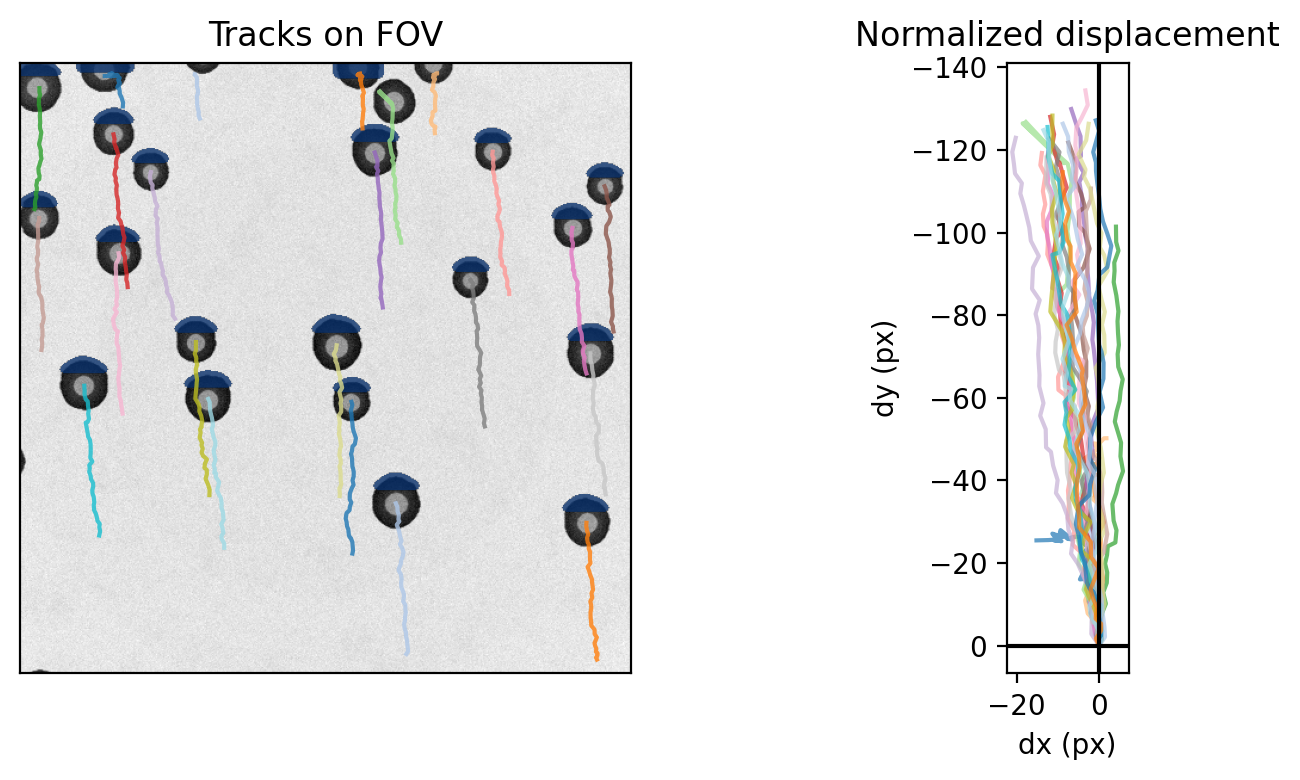

In [23]:
import pandas as pd
import tifffile
from glob import glob

tracks = pd.read_parquet(os.path.join(path, "tracks", "0_latest.parquet"))
particles = tracks["particle"].unique()

fig, axes = plt.subplots(1, 2, figsize=(8, 4),dpi = 200)

# --- Left: FOV overlay ---
ax = axes[0]
raw_files = sorted(glob(os.path.join(path, "raw", "*.tiff")))
last_img = tifffile.imread(raw_files[-1])
if last_img.ndim == 3:
    last_img = last_img[0]
ax.imshow(last_img, cmap="gray_r")

stim_files = sorted(glob(os.path.join(path, "stim_mask", "*.tiff")))
# Find the last non-zero stim mask
stim_mask_img = None
for sf in reversed(stim_files):
    candidate = tifffile.imread(sf)
    if candidate.any():
        stim_mask_img = candidate
        break
if stim_mask_img is not None:
    stim_overlay = np.ma.masked_where(stim_mask_img == 0, stim_mask_img)
    ax.imshow(stim_overlay, cmap="Blues", alpha=0.8, vmin=0, vmax=1)

ax.set_xticks([])
ax.set_yticks([])

cmap = plt.cm.tab20
for i, pid in enumerate(particles):
    t = tracks[tracks["particle"] == pid].sort_values("timestep")
    ax.plot(t["y"], t["x"], color=cmap(i % 20), lw=1.5, alpha=0.8)
ax.set_title("Tracks on FOV")


# --- Right: normalized displacement plot ---
ax = axes[1]

for i, pid in enumerate(particles):
    t = tracks[tracks["particle"] == pid].sort_values("timestep")
    x0, y0 = t.iloc[0]["x"], t.iloc[0]["y"]
    ax.plot(t["y"] - y0, t["x"] - x0, color=cmap(i % 20), alpha=0.7)
ax.set_xlabel("dx (px)")
ax.set_ylabel("dy (px)")
ax.set_title("Normalized displacement")
ax.set_aspect("equal")
ax.axhline(0, color="k")
ax.axvline(0, color="k")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Export stimulation overlay video

In [24]:
import imageio.v3 as iio

raw_files = sorted(glob(os.path.join(path, "raw", "*.tiff")))
stim_files = sorted(glob(os.path.join(path, "stim_mask", "*.tiff")))

frames = []
for raw_f, stim_f in zip(raw_files, stim_files):
    raw = tifffile.imread(raw_f)
    if raw.ndim == 3:
        raw = raw[0]
    stim = tifffile.imread(stim_f)

    # Normalize + invert (gray_r style) → uint8
    lo, hi = float(raw.min()), float(raw.max())
    raw_u8 = (255 - (raw - lo) / (hi - lo + 1e-8) * 255).astype(np.uint8)

    # Grayscale → RGB
    rgb = np.stack([raw_u8, raw_u8, raw_u8], axis=-1)

    # Blue overlay where stim mask is active
    mask = stim > 0
    if mask.any():
        alpha = 0.5
        blue = np.array([50, 120, 255], dtype=np.float32)
        rgb[mask] = (rgb[mask].astype(np.float32) * (1 - alpha) + blue * alpha).astype(np.uint8)

    frames.append(rgb)

output_mp4 = os.path.join(path, "stimulation_overlay.mp4")
iio.imwrite(output_mp4, np.stack(frames), fps=10, codec="libx264")
print(f"Saved {len(frames)}-frame video to {output_mp4}")

Saved 40-frame video to /tmp/test_optogenetic_sim/stimulation_overlay.mp4


## Multi-phase experiment: baseline → stim → recovery

Concatenate three `RTMSequence` objects with `+` to build a single event list.
Timepoints and `min_start_time` are automatically offset so the phases run back-to-back.

In [25]:
# Phase parameters
n_baseline = 10
n_stim = 30
n_recovery = 10
stim_fraction = 0.2

# Three RTMSequences — only the middle one has stimulation
baseline = RTMSequence(
    time_plan={"interval": 1.0, "loops": n_baseline},
    stage_positions=[(0.0, 0.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    rtm_metadata={"phase": "baseline"},
)

stim_phase = RTMSequence(
    time_plan={"interval": 1.0, "loops": n_stim},
    stage_positions=[(0.0, 0.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    stim_channels=[{"config": "phase-contrast", "exposure": 50}],
    stim_frames=range(n_stim),
    rtm_metadata={"phase": "stimulation"},
)

recovery = RTMSequence(
    time_plan={"interval": 1.0, "loops": n_recovery},
    stage_positions=[(0.0, 0.0, 0.0)],
    channels=[{"config": "phase-contrast", "exposure": 50}],
    rtm_metadata={"phase": "recovery"},
)

# Concatenate — timepoints and times are offset automatically
mp_events = baseline + stim_phase + recovery
n_total_mp = len(mp_events)

# Quick summary
df_mp = events_to_dataframe(mp_events)
print(f"{n_total_mp} events: {n_baseline} baseline + {n_stim} stim + {n_recovery} recovery")
print(f"Stim frames: {df_mp[df_mp['stim']]['timestep'].min()} – {df_mp[df_mp['stim']]['timestep'].max()}")
df_mp.head()

50 events: 10 baseline + 30 stim + 10 recovery
Stim frames: 10 – 39


,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,stim,optocheck_channels,optocheck,phase,stim_power,stim_exposure
0,0,0,0.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,baseline,NaN,NaN
1,0,1,1.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,baseline,NaN,NaN
2,0,2,2.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,baseline,NaN,NaN
3,0,3,3.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,baseline,NaN,NaN
4,0,4,4.0,0.0,0.0,0.0,"({'config': 'phase-contrast', 'exposure': 50.0...",(),False,(),False,baseline,NaN,NaN


In [26]:
# Fresh pipeline with StimUp for the multi-phase run
path_mp = "/tmp/test_optogenetic_sim_multiphase"
if os.path.exists(path_mp):
    shutil.rmtree(path_mp)

pipeline_mp = ImageProcessingPipeline(
    storage_path=path_mp,
    segmentators=segmentators,
    feature_extractor=SimpleFE("labels"),
    tracker=TrackerTrackpy(search_range=15),
    stimulator=StimUp(fraction=stim_fraction),
)

# Create controller with the new pipeline
ctrl_mp = Controller(mic, pipeline_mp)

# Run
pbar = tqdm(total=n_total_mp, desc="Multi-phase", unit="frames")
_frame_count_mp = [0]

def _on_frame_mp(img, event):
    md = event.metadata or {}
    if md.get("img_type") != ImgType.IMG_RAW:
        return
    _frame_count_mp[0] += 1
    pbar.update(1)

core.mda.events.frameReady.connect(_on_frame_mp)
_stdout = sys.stdout
sys.stdout = io.StringIO()
_mda_logger.setLevel(logging.WARNING)
try:
    ctrl_mp.run_experiment(mp_events, stim_mode="current")
    mic.post_experiment()
    ctrl_mp._analyzer.shutdown(wait=True)
finally:
    sys.stdout = _stdout
    _mda_logger.setLevel(_prev_level)
    try:
        core.mda.events.frameReady.disconnect(_on_frame_mp)
    except Exception:
        pass
    pbar.close()

print(f"Done — {_frame_count_mp[0]} frames acquired")

Directory /tmp/test_optogenetic_sim_multiphase/raw created 
Directory /tmp/test_optogenetic_sim_multiphase/tracks created 
Directory /tmp/test_optogenetic_sim_multiphase/stim_mask created 
Directory /tmp/test_optogenetic_sim_multiphase/stim created 
Directory /tmp/test_optogenetic_sim_multiphase/particles created 
Directory /tmp/test_optogenetic_sim_multiphase/labels created 


Multi-phase:   0%|          | 0/50 [00:00<?, ?frames/s]

Done — 50 frames acquired


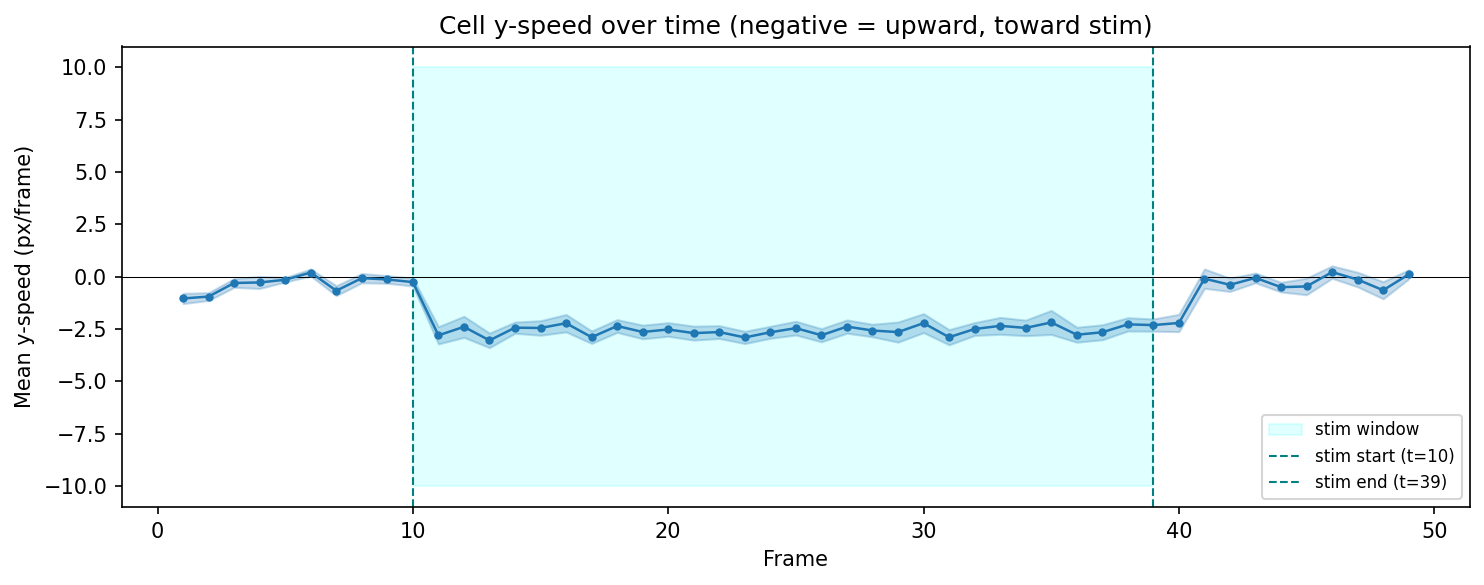

In [27]:
# Load tracks and compute per-frame mean y-speed (image x-axis = vertical)
tracks_mp = pd.read_parquet(os.path.join(path_mp, "tracks", "0_latest.parquet"))

# Per-particle y-displacement between consecutive frames
tracks_mp = tracks_mp.sort_values(["particle", "timestep"])
tracks_mp["dx"] = tracks_mp.groupby("particle")["x"].diff()  # image x = vertical (y)

# Mean speed per timestep (positive dx = downward in image coords → negative = upward)
speed_per_frame = tracks_mp.groupby("timestep")["dx"].agg(["mean", "sem"]).reset_index()

# Stim boundaries from the event list
stim_start_t = df_mp[df_mp["stim"]]["timestep"].min()
stim_end_t = df_mp[df_mp["stim"]]["timestep"].max()

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.fill_betweenx(
    [-10, 10], stim_start_t, stim_end_t,
    color="cyan", alpha=0.12, label="stim window",
)
ax.axvline(stim_start_t, ls="--", color="teal", lw=1, label=f"stim start (t={stim_start_t})")
ax.axvline(stim_end_t, ls="--", color="teal", lw=1, label=f"stim end (t={stim_end_t})")
ax.axhline(0, color="k", lw=0.5)

ax.plot(speed_per_frame["timestep"], speed_per_frame["mean"], "o-", ms=3, lw=1.2, color="tab:blue")
ax.fill_between(
    speed_per_frame["timestep"],
    speed_per_frame["mean"] - speed_per_frame["sem"],
    speed_per_frame["mean"] + speed_per_frame["sem"],
    alpha=0.25, color="tab:blue",
)

ax.set_xlabel("Frame")
ax.set_ylabel("Mean y-speed (px/frame)")
ax.set_title("Cell y-speed over time (negative = upward, toward stim)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()